# CL-SBI Quickstart Tutorial

A speed-run through the core data products of the CL-SBI pipeline.

This notebook loads outputs from a completed pipeline run and visualizes:

1. **Simulated M-c pairs** - Training data for the neural network
2. **Observed M-c pairs** - Test observations drawn from a richness bin
3. **Simulated NFW profiles** - Individual weak lensing profiles used for training
4. **Observed NFW profiles** - Noisy profiles we want to infer from
5. **M-c posteriors** - Comparing MCMC vs SBI inference


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pickle
import json
import sys
from pathlib import Path
import os

# Configure paths - adjust if needed
ROOT = Path("..")  # or Path("/path/to/CL-SBI")
plt.style.use(os.path.join(ROOT, "plot", "mplstyle.txt"))

# Add package to path for imports
sys.path.insert(0, str(ROOT))

SIM_ID = "sim_z1"
INFER_ID = "infer_z1"
OBS_ID = "obs_z1_lambda5"
NUM_SIMS = 10000
NUM_OBS = 376

sim_path = ROOT / f"outputs/simulations/{SIM_ID}.{NUM_SIMS}.{NUM_OBS}"
obs_path = ROOT / f"outputs/observations/{OBS_ID}.{NUM_OBS}"
infer_path = (
    ROOT / f"outputs/inference/{SIM_ID}.{INFER_ID}.{OBS_ID}.{NUM_SIMS}.{NUM_OBS}"
)

# Load configs to get richness bounds
with open(ROOT / f"configs/observations/{OBS_ID}.json") as f:
    obs_config = json.load(f)
with open(ROOT / f"configs/simulations/{SIM_ID}.json") as f:
    sim_config = json.load(f)

# Radial bins (kpc/h)
RBINS = 10 ** np.arange(0, 3, 0.1)

print(
    f"Observation richness bin: [{obs_config['min_richness']}, {obs_config['max_richness']}]"
)
print(
    f"Simulation richness bin: [{sim_config['min_richness']}, {sim_config['max_richness']}]"
)

Observation richness bin: [30, 45]
Simulation richness bin: [5, 45]


In [49]:
# Helper: convert richness to mass using mcclintock18 relation
def richness_to_mass(lambda_, z=0.275):
    """Convert richness to log10(mass) using McClintock+18 relation."""
    m0 = 3.081e14
    G = -0.3
    F = 1.356
    return np.log10(m0 * (lambda_ / 40) ** F * ((1 + z) / 1.35) ** G)


# Mass bounds corresponding to observation richness bin
obs_mass_min = richness_to_mass(obs_config["min_richness"])
obs_mass_max = richness_to_mass(obs_config["max_richness"])
print(f"Observation mass range: [{obs_mass_min:.2f}, {obs_mass_max:.2f}] log10(Msun)")

Observation mass range: [14.33, 14.57] log10(Msun)


## 1. Simulated M-c Pairs (Training Data)

Training data covers multiple richness bins, each mapping to a different region of the mass-concentration parameter space. Lower richness clusters have lower masses and higher concentrations; higher richness clusters have higher masses and lower concentrations.


In [50]:
# Shape: (n_sims, 7_percentiles, 2) where [:,:,0]=mass, [:,:,1]=conc
mc_percentiles = np.load(sim_path / "sample_mc_percentiles.npy")
print(f"MC percentiles shape: {mc_percentiles.shape}")
print(f"Percentile levels: [5, 16, 25, 50, 75, 84, 95]")

# Extract median for filtering later
sim_mc_50th = mc_percentiles[:, 3, :]  # 50th percentile (median)

# Filter to observation richness bin
in_obs_bin = (sim_mc_50th[:, 0] >= obs_mass_min) & (sim_mc_50th[:, 0] <= obs_mass_max)
sim_mc_filtered = sim_mc_50th[in_obs_bin]
print(f"Simulations in obs richness bin: {in_obs_bin.sum()} / {len(sim_mc_50th)}")

# Generate samples from each richness bin to show the distribution
from weaklensclustersbi.simulations.population import gen_mc_pairs_in_richness_bin

# Richness bins used in training (simulation range is [5, 45])
richness_bins = [(5, 10), (10, 14), (14, 20), (20, 30), (30, 45)]
bin_samples = {}

np.random.seed(42)
for lambda_min, lambda_max in richness_bins:
    samples = gen_mc_pairs_in_richness_bin(
        lambda_min=lambda_min,
        lambda_max=lambda_max,
        rm_relation=sim_config["rm_relation"],
        mc_relation=sim_config["mc_relation"],
        num_samples=2000,
        mc_scatter=sim_config["mc_scatter"],
        rm_scatter=sim_config["rm_scatter"],
        min_z=sim_config["min_z"],
        max_z=sim_config["max_z"],
    )
    bin_samples[(lambda_min, lambda_max)] = np.array(samples)
    print(
        f"  λ=[{lambda_min:2d}, {lambda_max:2d}]: n={len(samples)}, mass=[{np.mean(samples, axis=0)[0]:.2f}±{np.std(samples, axis=0)[0]:.2f}]"
    )

MC percentiles shape: (9996, 7, 2)
Percentile levels: [5, 16, 25, 50, 75, 84, 95]
Simulations in obs richness bin: 1428 / 9996
  λ=[ 5, 10]: n=2000, mass=[13.45±0.15]
  λ=[10, 14]: n=2000, mass=[13.75±0.12]
  λ=[14, 20]: n=2000, mass=[13.94±0.12]
  λ=[20, 30]: n=2000, mass=[14.16±0.12]
  λ=[30, 45]: n=2000, mass=[14.38±0.12]


In [51]:
def plot_kde_contours(ax, samples, color, label, levels=[0.95, 0.997], fill=True):
    """Plot 2D KDE contours at specified credible levels (2σ=0.95, 3σ=0.997)."""
    x, y = samples[:, 0], samples[:, 1]

    # Create grid for KDE
    xmin, xmax = x.min() - 0.2, x.max() + 0.2
    ymin, ymax = y.min() - 1, y.max() + 1
    xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])

    # KDE
    kernel = stats.gaussian_kde(samples.T)
    f = np.reshape(kernel(positions).T, xx.shape)

    # Find contour levels corresponding to credible intervals
    sorted_f = np.sort(f.ravel())[::-1]
    cumsum = np.cumsum(sorted_f)
    cumsum /= cumsum[-1]
    contour_levels = [sorted_f[np.searchsorted(cumsum, level)] for level in levels]
    contour_levels = sorted(contour_levels)

    # Plot contours
    if fill:
        ax.contourf(
            xx,
            yy,
            f,
            levels=[contour_levels[0], contour_levels[1], f.max()],
            colors=[color],
            alpha=[0.15, 0.35],
        )
    ax.contour(xx, yy, f, levels=contour_levels, colors=[color], linewidths=1.5)

    # Dummy for legend
    ax.plot([], [], color=color, lw=2, label=label)

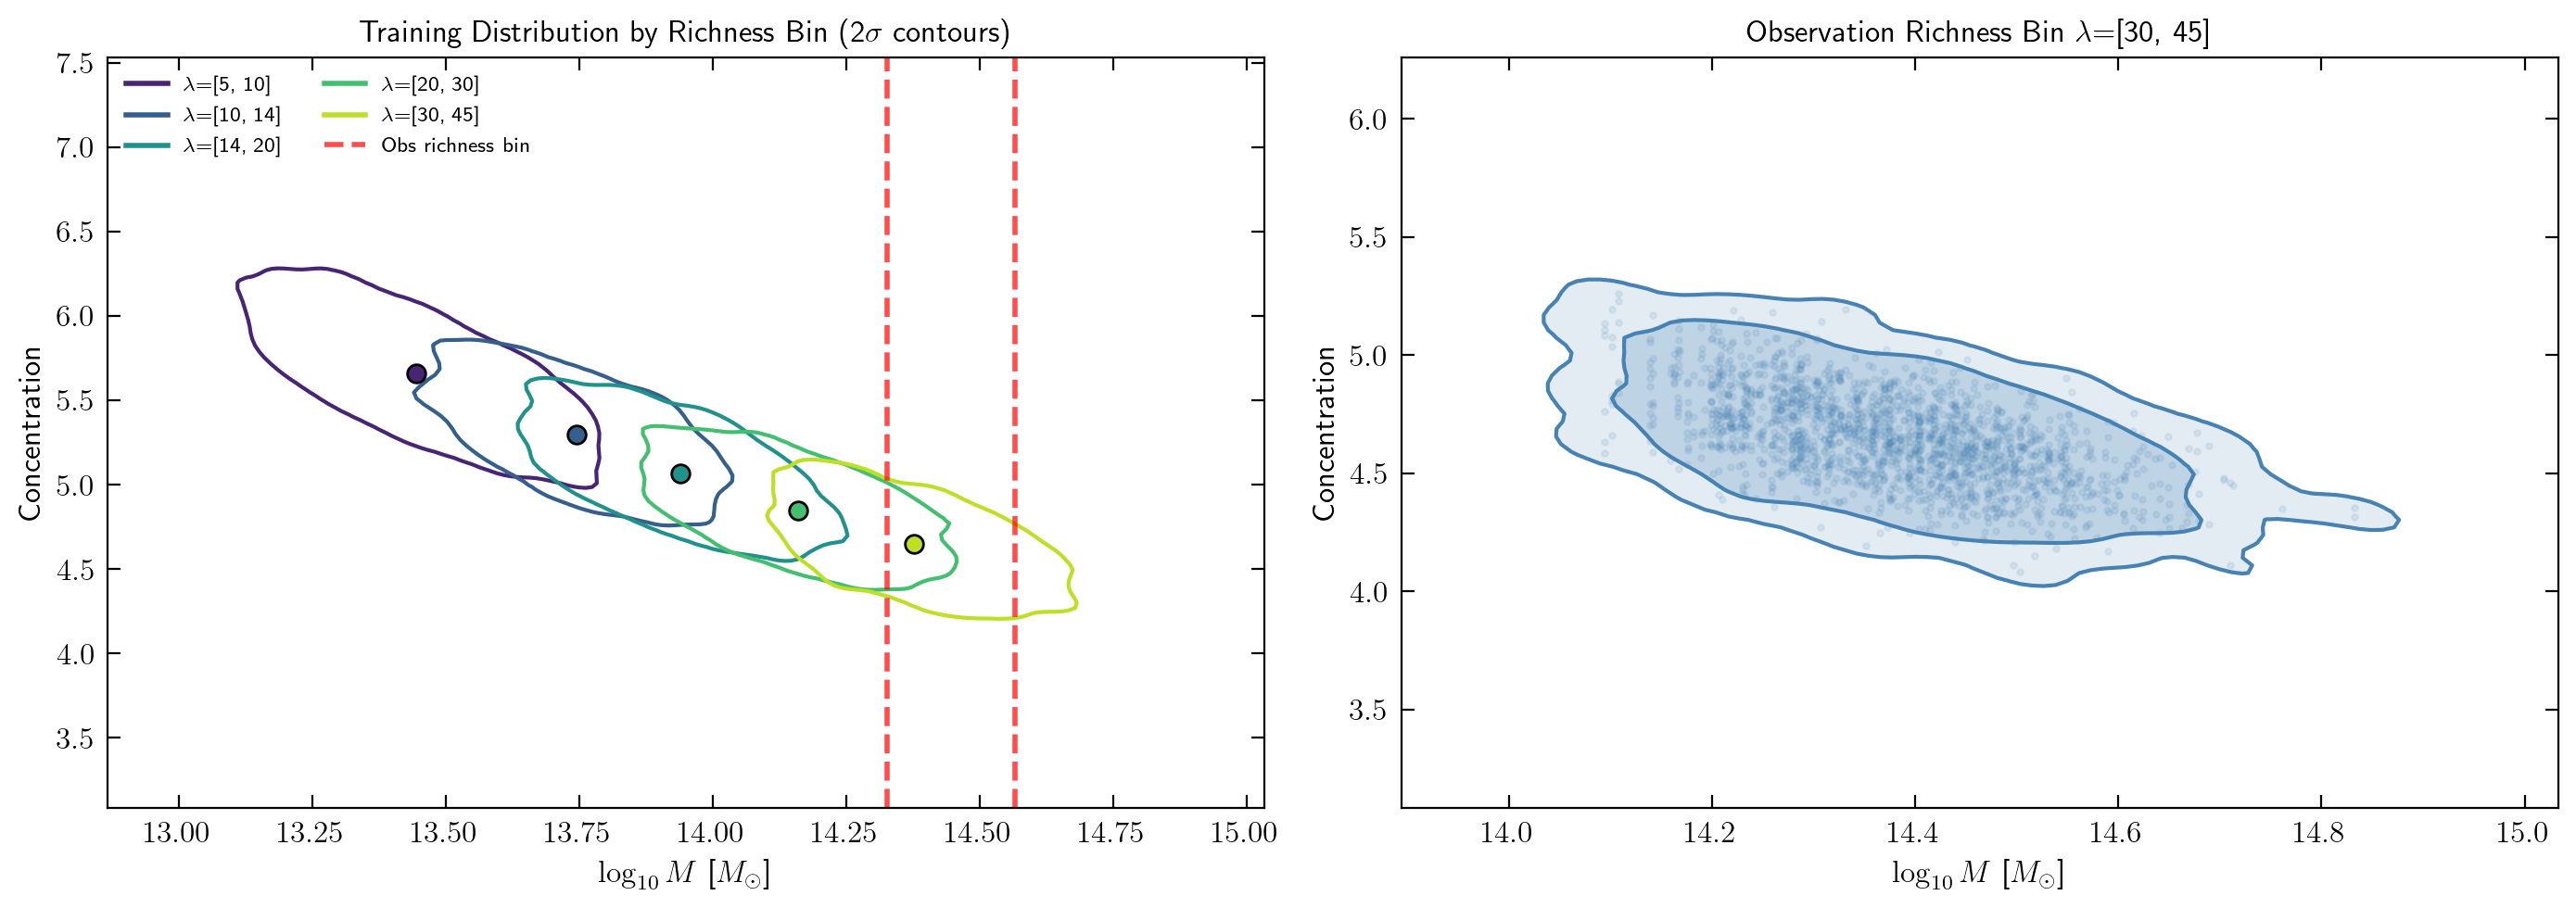

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color map for richness bins
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(richness_bins)))

# Left: Gaussian contours per richness bin showing training coverage
ax = axes[0]
for idx, ((lambda_min, lambda_max), samples) in enumerate(bin_samples.items()):
    # Plot 2σ contour for each bin
    plot_kde_contours(
        ax,
        samples,
        colors[idx],
        rf"$\lambda$=[{lambda_min}, {lambda_max}]",
        levels=[0.95],
        fill=False,
    )
    # Mark the mean
    ax.scatter(
        np.mean(samples[:, 0]),
        np.mean(samples[:, 1]),
        c=[colors[idx]],
        s=50,
        marker="o",
        edgecolors="k",
        zorder=5,
    )

ax.axvline(obs_mass_min, color="red", ls="--", lw=2, alpha=0.7)
ax.axvline(
    obs_mass_max, color="red", ls="--", lw=2, alpha=0.7, label="Obs richness bin"
)
ax.set_xlabel(r"$\log_{10} M$ [$M_\odot$]", fontsize=12)
ax.set_ylabel("Concentration", fontsize=12)
ax.set_title(r"Training Distribution by Richness Bin (2$\sigma$ contours)")
ax.legend(fontsize=8, loc="upper left", ncol=2)

# Right: Zoom into observation richness bin
ax = axes[1]
obs_bin_key = (30, 45)
obs_bin_samples = bin_samples[obs_bin_key]
plot_kde_contours(
    ax, obs_bin_samples, "steelblue", rf"$\lambda$={obs_bin_key} (2σ, 3σ)"
)
ax.scatter(obs_bin_samples[:, 0], obs_bin_samples[:, 1], alpha=0.1, s=5, c="steelblue")
ax.set_xlabel(r"$\log_{10} M$ [$M_\odot$]", fontsize=12)
ax.set_ylabel("Concentration", fontsize=12)
ax.set_title(
    rf"Observation Richness Bin $\lambda$=[{obs_bin_key[0]}, {obs_bin_key[1]}]"
)

plt.tight_layout()

## 2. Observed M-c Pairs & Training Distribution

The "true" M-c values for our test observations, overlaid on the KDE of the training distribution from which they're drawn.


In [53]:
obs_mc_pairs = np.load(obs_path / "drawn_mc_pairs.npy")
true_median = np.load(infer_path / "true_param_median.npy")
print(f"Observed M-c pairs shape: {obs_mc_pairs.shape}")
print(f"True median (log10M, c): ({true_median[0]:.2f}, {true_median[1]:.2f})")

# Generate more samples from the observation distribution for smoother KDE
# This is the distribution from which observations are drawn
from weaklensclustersbi.simulations.population import gen_mc_pairs_in_richness_bin

np.random.seed(42)
obs_dist_samples = gen_mc_pairs_in_richness_bin(
    lambda_min=obs_config["min_richness"],
    lambda_max=obs_config["max_richness"],
    rm_relation=obs_config["rm_relation"],
    mc_relation=obs_config["mc_relation"],
    num_samples=5000,  # Generate many samples for smooth KDE
    mc_scatter=obs_config["mc_scatter"],
    rm_scatter=obs_config["rm_scatter"],
    min_z=obs_config["min_z"],
    max_z=obs_config["max_z"],
)
obs_dist_samples = np.array(obs_dist_samples)
print(f"Observation distribution samples: {obs_dist_samples.shape}")

Observed M-c pairs shape: (376, 2)
True median (log10M, c): (14.36, 4.66)
Observation distribution samples: (5000, 2)


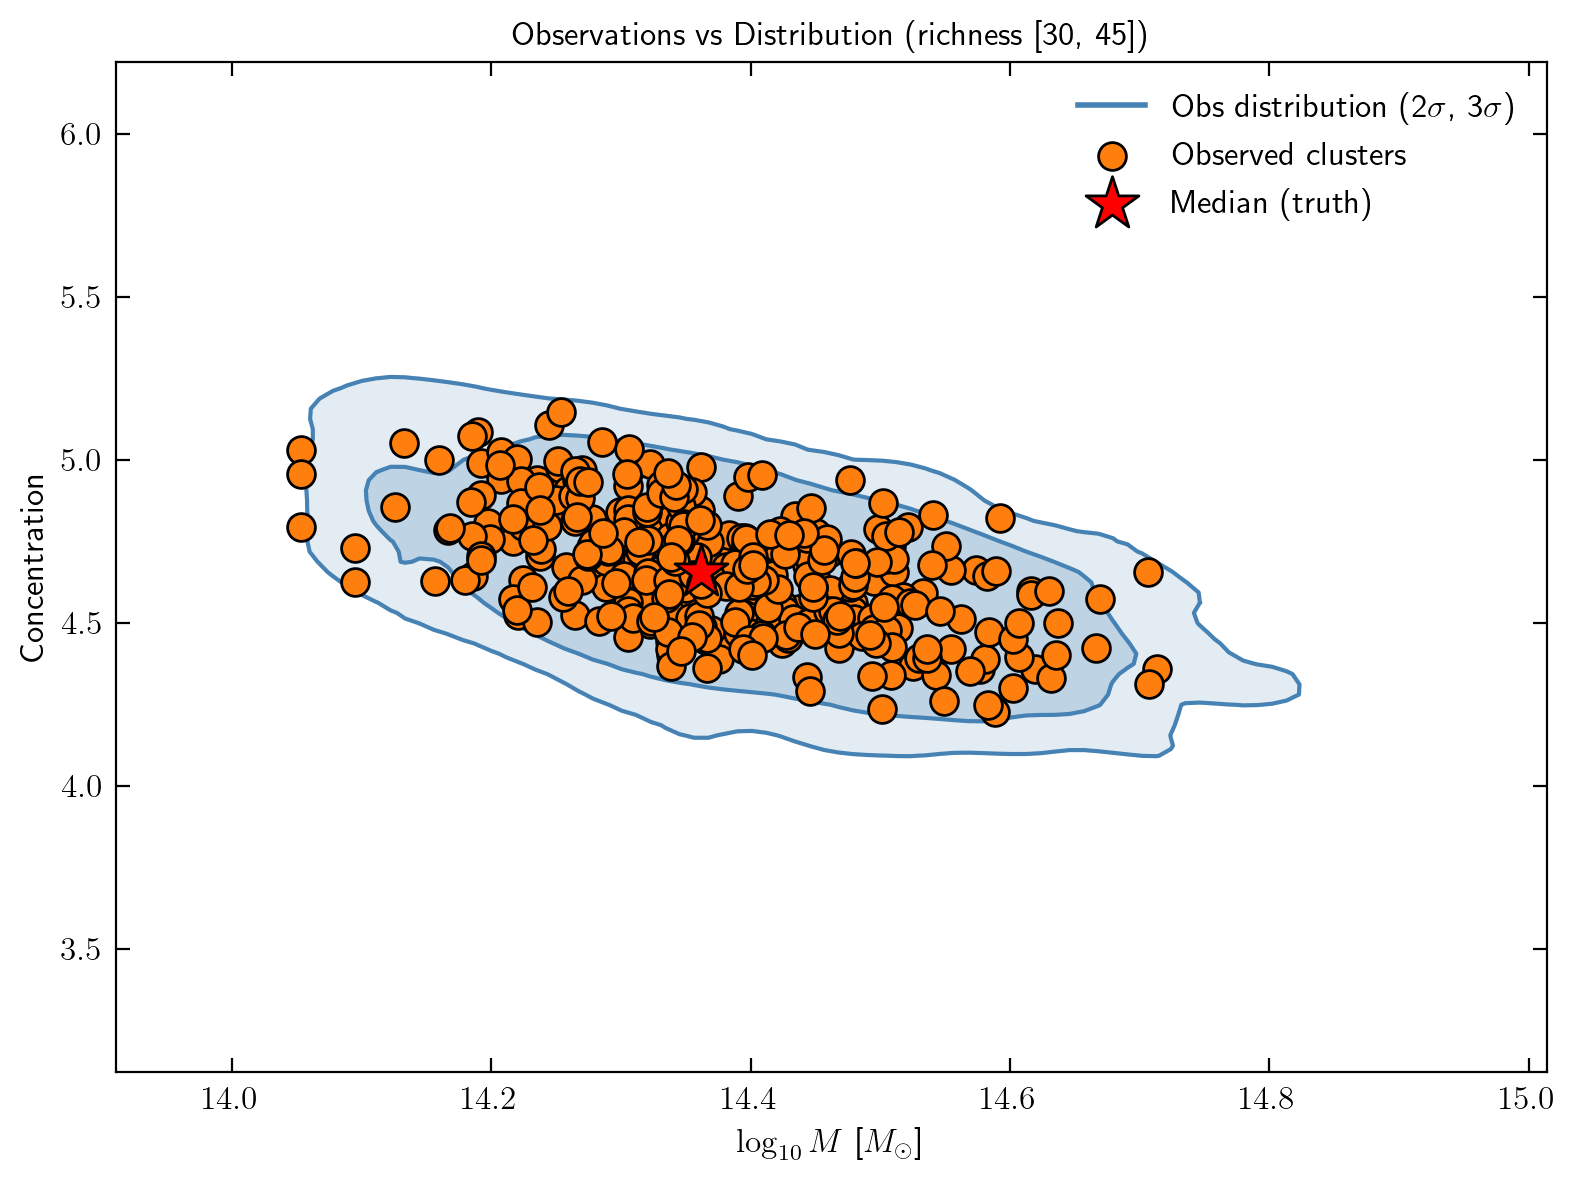

In [55]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot KDE of the observation distribution (from which obs are drawn)
plot_kde_contours(
    ax, obs_dist_samples, "steelblue", r"Obs distribution (2$\sigma$, 3$\sigma$)"
)

# Plot observed clusters
ax.scatter(
    obs_mc_pairs[:, 0],
    obs_mc_pairs[:, 1],
    s=100,
    c="C1",
    edgecolors="k",
    zorder=10,
    label="Observed clusters",
)
ax.scatter(
    true_median[0],
    true_median[1],
    marker="*",
    s=400,
    c="red",
    edgecolors="k",
    zorder=11,
    label="Median (truth)",
)

ax.set_xlabel(r"$\log_{10} M$ [$M_\odot$]", fontsize=12)
ax.set_ylabel("Concentration", fontsize=12)
ax.set_title(
    f"Observations vs Distribution (richness [{obs_config['min_richness']}, {obs_config['max_richness']}])"
)
ax.legend(loc="upper right")
plt.tight_layout()

## 3. Simulated NFW Profiles (Training Data)

Individual noisy weak lensing surface density profiles used for training, filtered to the observation richness bin.


In [ ]:
# Individual profiles: shape (n_sims, n_obs, n_radial_bins)
sim_profiles = np.load(sim_path / "simulated_nfw_profiles.npy")
print(f"Simulated profiles shape: {sim_profiles.shape}")
print(
    f"  -> {sim_profiles.shape[0]} simulations x {sim_profiles.shape[1]} obs/sim x {sim_profiles.shape[2]} radial bins"
)

# Filter to observation richness bin
sim_profiles_filtered = sim_profiles[in_obs_bin]
print(f"Filtered profiles shape: {sim_profiles_filtered.shape}")

Simulated profiles shape: (9996, 376, 30)
  -> 9996 simulations x 376 obs/sim x 30 radial bins
Filtered profiles shape: (1428, 376, 30)


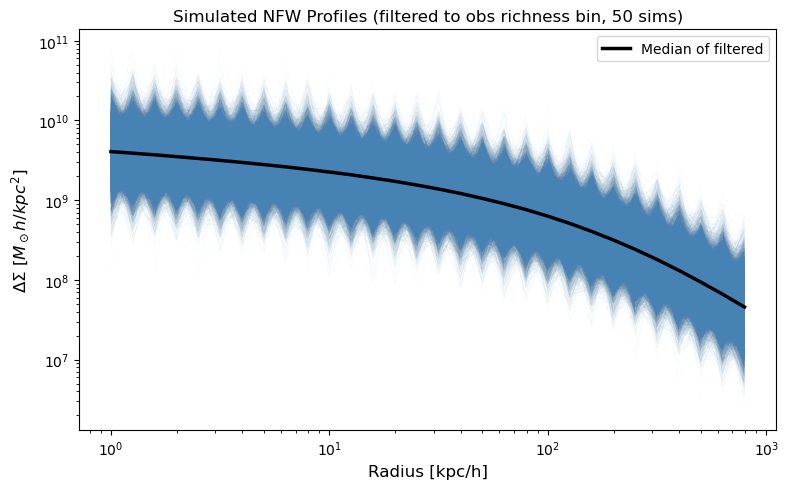

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# Plot individual profiles from filtered simulations
n_to_plot = min(50, len(sim_profiles_filtered))
for i in range(n_to_plot):
    for j in range(sim_profiles_filtered.shape[1]):
        ax.loglog(
            RBINS,
            10 ** sim_profiles_filtered[i, j, :],
            alpha=0.03,
            color="steelblue",
            lw=0.5,
        )

# Compute and plot overall median of filtered profiles
all_filtered = sim_profiles_filtered.reshape(-1, sim_profiles_filtered.shape[-1])
median_profile = np.median(all_filtered, axis=0)
ax.loglog(RBINS, 10**median_profile, "k-", lw=2.5, label="Median of filtered")

ax.set_xlabel("Radius [kpc/h]", fontsize=12)
ax.set_ylabel(r"$\Delta\Sigma$ [$M_\odot h / kpc^2$]", fontsize=12)
ax.set_title(f"Simulated NFW Profiles (filtered to obs richness bin, {n_to_plot} sims)")
ax.legend()
plt.tight_layout()

## 4. Observed NFW Profiles (Test Data)

Noisy weak lensing profiles we want to infer M-c from.


Observed profiles shape: (376, 30)


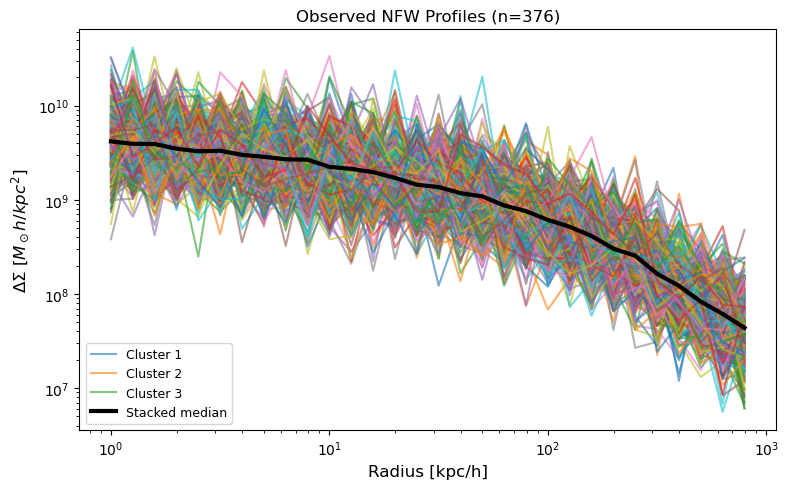

In [ ]:
obs_profiles = np.load(obs_path / "drawn_nfw_profiles.npy")
sigmas = np.load(obs_path / "sigmas.npy")
print(f"Observed profiles shape: {obs_profiles.shape}")

fig, ax = plt.subplots(figsize=(8, 5))
for i, profile in enumerate(obs_profiles):
    ax.loglog(
        RBINS, 10**profile, alpha=0.6, lw=1.5, label=f"Cluster {i+1}" if i < 3 else None
    )

# Show stacked median with error bars
median_obs = np.median(obs_profiles, axis=0)
ax.loglog(RBINS, 10**median_obs, "k-", lw=3, label="Stacked median")
upper = 10 ** (median_obs + sigmas / np.sqrt(len(obs_profiles)))
lower = 10 ** (median_obs - sigmas / np.sqrt(len(obs_profiles)))
ax.fill_between(RBINS, lower, upper, alpha=0.3, color="gray")

ax.set_xlabel("Radius [kpc/h]", fontsize=12)
ax.set_ylabel(r"$\Delta\Sigma$ [$M_\odot h / kpc^2$]", fontsize=12)
ax.set_title(f"Observed NFW Profiles (n={len(obs_profiles)})")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()

## 5. M-c Posteriors: MCMC vs SBI

Comparison of inferred M-c posteriors using traditional MCMC and neural SBI. Contours show 2σ (95%) and 3σ (99.7%) credible regions.


In [ ]:
# Load MCMC chains
with open(infer_path / "mcmc_chains.pickle", "rb") as f:
    mcmc_chains = pickle.load(f)
mcmc_jtf = mcmc_chains[0][:, :2]  # Join-then-fit, drop log_f param
mcmc_ftj = mcmc_chains[1][:, :2]  # Fit-then-join

# Load SBI chains
with open(infer_path / "sbi_chains.pickle", "rb") as f:
    sbi_chains = pickle.load(f)
sbi_jtf = sbi_chains[0]
sbi_ftj = sbi_chains[1]

# SBI outputs percentiles - extract median (index 3 = 50th percentile)
# Percentile levels: [5, 16, 25, 50, 75, 84, 95]
n_levels = 7
med_idx = 3  # 50th percentile
idx_16 = 1  # 16th percentile
idx_84 = 5  # 84th percentile

# For SBI JTF: use median samples directly (joint inference on stacked profile)
sbi_jtf_mc = np.column_stack([sbi_jtf[:, med_idx], sbi_jtf[:, n_levels + med_idx]])

# For SBI FTJ: create Gaussian approximation using percentile spread
# This matches how plot_chainconsumer generates the sbi_cc plot
mass_percentiles = sbi_ftj[:, :n_levels]
conc_percentiles = sbi_ftj[:, n_levels : 2 * n_levels]
correlations = sbi_ftj[:, -1]

# Estimate mu as median of the 50th percentile samples
mu_mass = np.median(mass_percentiles[:, med_idx])
mu_conc = np.median(conc_percentiles[:, med_idx])

# Estimate sigma from percentile spread (84th - 16th) / 2
sigma_mass = (
    np.median(mass_percentiles[:, idx_84]) - np.median(mass_percentiles[:, idx_16])
) / 2.0
sigma_conc = (
    np.median(conc_percentiles[:, idx_84]) - np.median(conc_percentiles[:, idx_16])
) / 2.0
rho = np.median(np.clip(correlations, -0.99, 0.99))

# Generate Gaussian samples to match plotutils behavior
cov = np.array(
    [
        [sigma_mass**2, rho * sigma_mass * sigma_conc],
        [rho * sigma_mass * sigma_conc, sigma_conc**2],
    ]
)
rng = np.random.default_rng(42)
sbi_ftj_mc = rng.multivariate_normal(mean=[mu_mass, mu_conc], cov=cov, size=10000)

print(f"MCMC JTF samples: {len(mcmc_jtf):,}")
print(f"SBI JTF samples: {len(sbi_jtf_mc):,}")
print(f"\nFTJ spread comparison:")
print(
    f"  MCMC FTJ: mass_std={np.std(mcmc_ftj[:,0]):.3f}, conc_std={np.std(mcmc_ftj[:,1]):.3f}"
)
print(f"  SBI FTJ:  sigma_mass={sigma_mass:.3f}, sigma_conc={sigma_conc:.3f}")

MCMC JTF samples: 50,000
SBI JTF samples: 10,000

FTJ spread comparison:
  MCMC FTJ: mass_std=0.105, conc_std=0.137
  SBI FTJ:  sigma_mass=0.109, sigma_conc=0.190


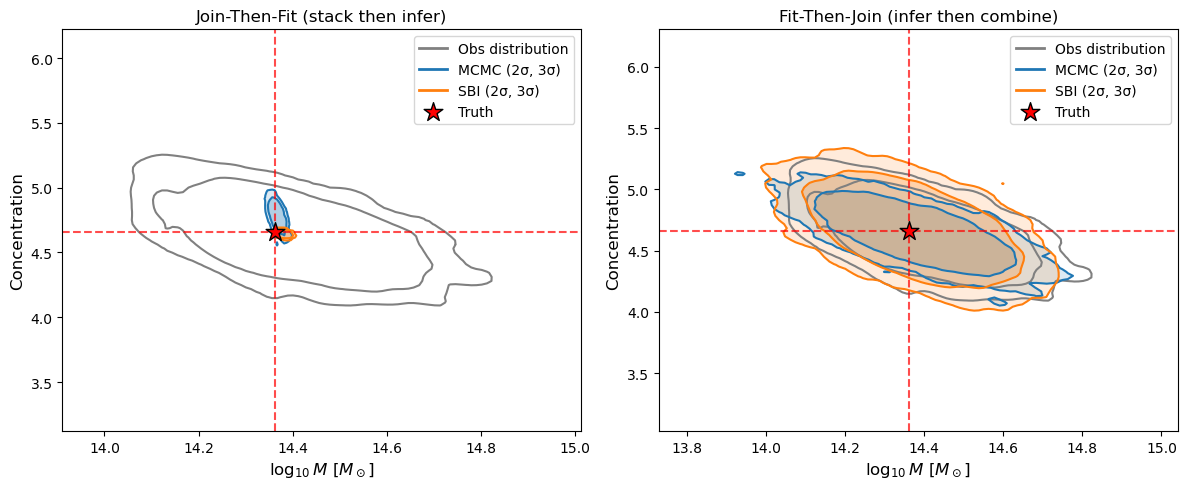

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Join-then-fit comparison
ax = axes[0]
plot_kde_contours(ax, obs_dist_samples, "gray", "Obs distribution", fill=False)
plot_kde_contours(ax, mcmc_jtf, "C0", "MCMC (2σ, 3σ)")
plot_kde_contours(ax, sbi_jtf_mc, "C1", "SBI (2σ, 3σ)")
ax.axvline(true_median[0], color="red", ls="--", lw=1.5, alpha=0.7)
ax.axhline(true_median[1], color="red", ls="--", lw=1.5, alpha=0.7)
ax.scatter(
    true_median[0],
    true_median[1],
    marker="*",
    s=200,
    c="red",
    edgecolors="k",
    zorder=10,
    label="Truth",
)
ax.set_xlabel(r"$\log_{10} M$ [$M_\odot$]", fontsize=12)
ax.set_ylabel("Concentration", fontsize=12)
ax.set_title("Join-Then-Fit (stack then infer)")
ax.legend(loc="upper right")

# Fit-then-join comparison
ax = axes[1]
plot_kde_contours(ax, obs_dist_samples, "gray", "Obs distribution", fill=False)
plot_kde_contours(ax, mcmc_ftj, "C0", "MCMC (2σ, 3σ)")
plot_kde_contours(ax, sbi_ftj_mc, "C1", "SBI (2σ, 3σ)")
ax.axvline(true_median[0], color="red", ls="--", lw=1.5, alpha=0.7)
ax.axhline(true_median[1], color="red", ls="--", lw=1.5, alpha=0.7)
ax.scatter(
    true_median[0],
    true_median[1],
    marker="*",
    s=200,
    c="red",
    edgecolors="k",
    zorder=10,
    label="Truth",
)
ax.set_xlabel(r"$\log_{10} M$ [$M_\odot$]", fontsize=12)
ax.set_ylabel("Concentration", fontsize=12)
ax.set_title("Fit-Then-Join (infer then combine)")
ax.legend(loc="upper right")

plt.tight_layout()

### 1D Marginal Posteriors


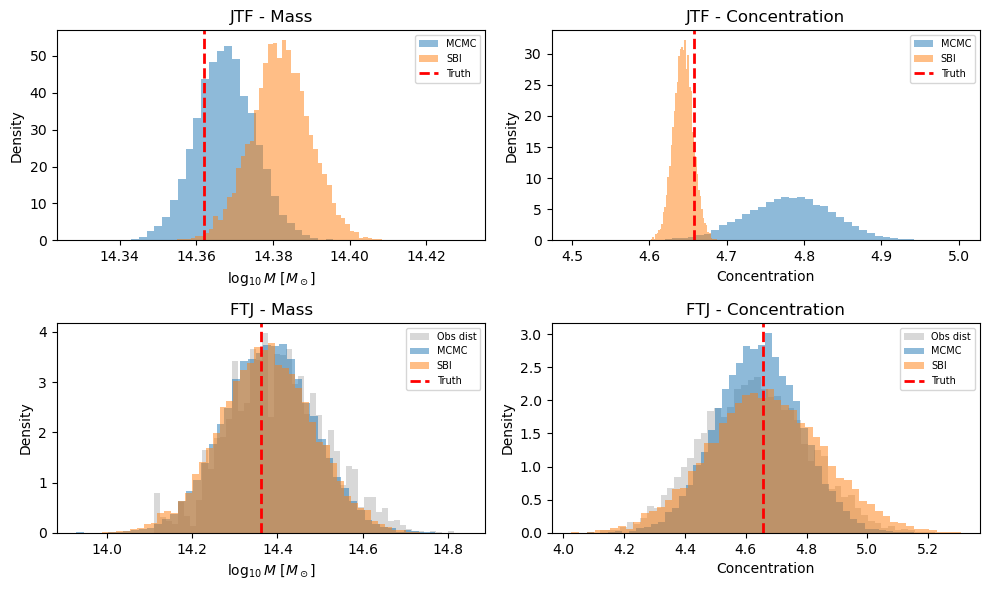

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# JTF - Mass
ax = axes[0, 0]
# ax.hist(obs_dist_samples[:, 0], bins=50, density=True, alpha=0.3, label="Obs dist", color="gray")
ax.hist(mcmc_jtf[:, 0], bins=50, density=True, alpha=0.5, label="MCMC", color="C0")
ax.hist(sbi_jtf_mc[:, 0], bins=50, density=True, alpha=0.5, label="SBI", color="C1")
ax.axvline(true_median[0], color="red", ls="--", lw=2, label="Truth")
ax.set_xlabel(r"$\log_{10} M$ [$M_\odot$]")
ax.set_ylabel("Density")
ax.set_title("JTF - Mass")
ax.legend(fontsize=7)

# JTF - Concentration
ax = axes[0, 1]
# ax.hist(obs_dist_samples[:, 1], bins=50, density=True, alpha=0.3, label="Obs dist", color="gray")
ax.hist(mcmc_jtf[:, 1], bins=50, density=True, alpha=0.5, label="MCMC", color="C0")
ax.hist(sbi_jtf_mc[:, 1], bins=50, density=True, alpha=0.5, label="SBI", color="C1")
ax.axvline(true_median[1], color="red", ls="--", lw=2, label="Truth")
ax.set_xlabel("Concentration")
ax.set_ylabel("Density")
ax.set_title("JTF - Concentration")
ax.legend(fontsize=7)

# FTJ - Mass
ax = axes[1, 0]
ax.hist(
    obs_dist_samples[:, 0],
    bins=50,
    density=True,
    alpha=0.3,
    label="Obs dist",
    color="gray",
)
ax.hist(mcmc_ftj[:, 0], bins=50, density=True, alpha=0.5, label="MCMC", color="C0")
ax.hist(sbi_ftj_mc[:, 0], bins=50, density=True, alpha=0.5, label="SBI", color="C1")
ax.axvline(true_median[0], color="red", ls="--", lw=2, label="Truth")
ax.set_xlabel(r"$\log_{10} M$ [$M_\odot$]")
ax.set_ylabel("Density")
ax.set_title("FTJ - Mass")
ax.legend(fontsize=7)

# FTJ - Concentration
ax = axes[1, 1]
ax.hist(
    obs_dist_samples[:, 1],
    bins=50,
    density=True,
    alpha=0.3,
    label="Obs dist",
    color="gray",
)
ax.hist(mcmc_ftj[:, 1], bins=50, density=True, alpha=0.5, label="MCMC", color="C0")
ax.hist(sbi_ftj_mc[:, 1], bins=50, density=True, alpha=0.5, label="SBI", color="C1")
ax.axvline(true_median[1], color="red", ls="--", lw=2, label="Truth")
ax.set_xlabel("Concentration")
ax.set_ylabel("Density")
ax.set_title("FTJ - Concentration")
ax.legend(fontsize=7)

plt.tight_layout()

## Summary Statistics


In [ ]:
def summarize(samples, name):
    m_med, c_med = np.median(samples, axis=0)
    m_std, c_std = np.std(samples, axis=0)
    print(
        f"{name:15s} | log10M = {m_med:5.2f} +/- {m_std:.2f} | c = {c_med:5.2f} +/- {c_std:.2f}"
    )


print(f"{'Method':15s} | {'Mass':20s} | {'Concentration'}")
print("-" * 55)
print(
    f"{'Truth':15s} | log10M = {true_median[0]:5.2f}        | c = {true_median[1]:5.2f}"
)
print("-" * 55)
summarize(mcmc_jtf, "MCMC JTF")
summarize(sbi_jtf_mc, "SBI JTF")
print("-" * 55)
summarize(mcmc_ftj, "MCMC FTJ")
summarize(sbi_ftj_mc, "SBI FTJ*")
print(
    "\n* SBI FTJ uses Gaussian approximation from percentile spread (matches sbi_cc plots)"
)

Method          | Mass                 | Concentration
-------------------------------------------------------
Truth           | log10M = 14.36        | c =  4.66
-------------------------------------------------------
MCMC JTF        | log10M = 14.37 +/- 0.01 | c =  4.78 +/- 0.06
SBI JTF         | log10M = 14.38 +/- 0.01 | c =  4.64 +/- 0.01
-------------------------------------------------------
MCMC FTJ        | log10M = 14.38 +/- 0.10 | c =  4.64 +/- 0.14
SBI FTJ*        | log10M = 14.37 +/- 0.11 | c =  4.66 +/- 0.19

* SBI FTJ uses Gaussian approximation from percentile spread (matches sbi_cc plots)
